# VeloceReduction — Reduce one observing night

This notebook is the master workflow for reducing a complete Veloce observing
night.

**Input:** `observations/YYMMDD/`  
**Output:** `reductions/vr_X.Y.Z/YYMMDD/`

Detailed algorithms are implemented in the `velocereduction` Python modules.
This notebook intentionally contains only the main reduction steps.

## 0. Setup

Choose the night and reduction settings.

When run interactively as a notebook, the values below are used directly.
When converted to `reduce_night.py`, the night is supplied on the command line.

In [1]:
import sys
import argparse

import numpy as np

from astropy.table import Table

import matplotlib.pyplot as plt

from velocereduction import (
    __version__,
    utils,
    flat,
    tramlines,
    calibration,
    wavelength
)


def running_in_notebook():
    """True for an interactive Jupyter notebook, False for reduce_night.py."""
    if 'ipykernel' in sys.modules:
        return True
    else:
        return False


IN_NOTEBOOK = running_in_notebook()

In [2]:
if IN_NOTEBOOK:

    # -------------------------------------------------------------------------
    # Interactive notebook settings
    # -------------------------------------------------------------------------

    night = '001122'            # Observing night in YYMMDD format,
                                # e.g. 001122, which is the reference night
    # night = '260703'            

    log_level = 'DEBUG'          # DEBUG / INFO / WARNING / ERROR
    diagnostics = 'full'       # none / basic / full

    extraction_mode = 'summed'  # summed / fibre
    overwrite = False

else:

    # -------------------------------------------------------------------------
    # Command-line settings for reduce_night.py
    # -------------------------------------------------------------------------

    parser = argparse.ArgumentParser(
        description='Reduce one complete Veloce observing night.'
    )

    parser.add_argument(
        'night',
        help='Observing night in YYMMDD format, e.g. 001122'
    )

    parser.add_argument(
        '--log-level',
        choices=['DEBUG', 'INFO', 'WARNING', 'ERROR'],
        default='INFO'
    )

    parser.add_argument(
        '--diagnostics',
        choices=['none', 'basic', 'full'],
        default='basic'
    )

    parser.add_argument(
        '--extraction-mode',
        choices=['summed', 'fibre'],
        default='summed'
    )

    parser.add_argument(
        '--overwrite',
        action='store_true'
    )

    args = parser.parse_args()

    night = args.night
    log_level = args.log_level
    diagnostics = args.diagnostics
    extraction_mode = args.extraction_mode
    overwrite = args.overwrite

In [3]:
config = utils.ReductionConfig(
    night=night,
    log_level=log_level,
    diagnostics=diagnostics,
    extraction_mode=extraction_mode,
    overwrite=overwrite,
)

paths = utils.prepare_reduction(config, version=__version__)
logger = utils.setup_logging(config, paths)

logger.info('Starting VeloceReduction %s for night %s', __version__, night)
logger.info('Diagnostics: %s', diagnostics)
logger.info('Extraction mode: %s', extraction_mode)

print(f'\nNight:             {night}')
print(f'VeloceReduction:   {__version__}')
print(f'Logging:           {log_level}')
print(f'Diagnostics:       {diagnostics}')
print(f'Extraction:        {extraction_mode}')
print(f'Output:            {paths.root}')

INFO     ========================================================================
INFO     Starting VeloceReduction
INFO     Night: 001122
INFO     Log level: DEBUG
INFO     Diagnostics: full
INFO     Extraction mode: summed
INFO     Output directory: /Users/buder/velocereduction/reductions/vr_0.7.0/001122
INFO     Starting VeloceReduction 0.7.0 for night 001122
INFO     Diagnostics: full
INFO     Extraction mode: summed

Night:             001122
VeloceReduction:   0.7.0
Logging:           DEBUG
Diagnostics:       full
Extraction:        summed
Output:            /Users/buder/velocereduction/reductions/vr_0.7.0/001122


## 1. Identify observations

**Input:** raw observations and observing log  
**Output:** night overview and `reduction_input_YYMMDD.txt`

All observations are classified once at the beginning of the reduction.
Later stages use this table rather than repeatedly reading and classifying
raw FITS headers.

In [4]:
reduction_input = utils.identify_observations(config, paths)

utils.write_reduction_input(reduction_input, config, paths)

if IN_NOTEBOOK:
    display(reduction_input)

INFO     Using observing log 001122-AAT-reference.log
INFO     Identified 20 observing runs
INFO       Dark       3
INFO       FibTh      3
INFO       Flat       3
INFO       Science    7
INFO       SimLC      1
INFO       SimTh      3
INFO     Wrote reduction input to /Users/buder/velocereduction/reductions/vr_0.7.0/001122/reduction_input_001122.txt


run,type,object,exptime,mjd_obs,mjd_mid,has_ccd1,has_ccd2,has_ccd3,use_ccd1,use_ccd2,use_ccd3,file_ccd1,file_ccd2,file_ccd3,files_complete,use,lc_requested,lc_ut,lc_exp,comments,issue,calibration_block
str4,str7,str16,float64,float64,float64,bool,bool,bool,bool,bool,bool,str70,str70,str70,bool,bool,bool,str8,float64,str44,str18,str16
0001,SimTh,SimThLong,180.0,60359.34174913,60359.34279079667,True,False,False,True,False,False,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10001.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20001.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30001.fits,False,True,False,,nan,N/A to limit storage,"Missing CCD2, CCD3",cal003
0002,SimTh,SimThLong,60.0,60359.35892373,60359.35927095222,False,True,False,False,True,False,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10002.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20002.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30002.fits,False,True,False,,nan,N/A to limit storage,"Missing CCD1, CCD3",cal003
0003,SimTh,SimTh,15.0,60359.36918084,60359.36926764556,False,False,True,False,False,True,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10003.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20003.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30003.fits,False,True,False,,nan,Median of 10 runs from 240219.,"Missing CCD1, CCD2",cal003
0004,FibTh,ARC-ThAr,180.0,60359.32203372,60359.32307538667,True,False,False,True,False,False,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10004.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20004.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30004.fits,False,True,False,,nan,N/A to limit storage,"Missing CCD2, CCD3",cal003
0005,FibTh,ARC-ThAr,60.0,60359.3114762,60359.31182342222,False,True,False,False,True,False,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10005.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20005.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30005.fits,False,True,False,,nan,N/A to limit storage,"Missing CCD1, CCD3",cal003
0006,FibTh,ARC-ThAr,15.0,60359.30351276,60359.30359956556,False,False,True,False,False,True,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10006.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20006.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30006.fits,False,True,False,,nan,Median of 16 runs from 240219.,"Missing CCD1, CCD2",cal003
0007,SimLC,SimLC,6.0,60359.23438043,60359.23441515223,False,True,True,False,True,True,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10007.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20007.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30007.fits,True,True,True,05:37:32,1.0,Median of 21 runs from 240219.,,cal001
0008,Flat,FlatField-Quartz,60.0,60359.28635215,60359.28669937222,True,False,False,True,False,False,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10008.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20008.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30008.fits,False,True,False,,nan,BAD BAD BAD N/A to limit storage,"Missing CCD2, CCD3",cal003
0009,Flat,FlatField-Quartz,1.0,60359.26552574,60359.26553152703,False,True,False,False,True,False,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10009.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20009.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30009.fits,False,True,False,,nan,N/A to limit storage,"Missing CCD1, CCD3",cal002


## 2. Measure displacement relative to reference night

Measure the displacement of each detector relative to the reference night.

SimTh images are used for all three CCDs, with SimLC providing an additional
registration measurement for CCD2 and CCD3.

In [5]:
detector_shifts = tramlines.measure_detector_shifts(
    reduction_input,
    config,
    paths,
)

if IN_NOTEBOOK:
    display(detector_shifts)

INFO     Reference night 001122: detector shifts are (0, 0)


ccd,dx,dy,dx_scatter,dy_scatter,n_used,sources,status
int64,float64,float64,float64,float64,int64,str9,str9
1,0.0,0.0,0.0,0.0,0,reference,reference
2,0.0,0.0,0.0,0.0,0,reference,reference
3,0.0,0.0,0.0,0.0,0,reference,reference


## 3. Master Flat, nightly tramlines, and Flat response

**Input:** Flat observations + reference tramlines + detector shifts  
**Output:** master Flat, nightly tramline geometry, extracted Flat, response Flat, and blaze function

Create a high-S/N master Flat in detector coordinates and use it to determine
the nightly tramline geometry. The Flat is then extracted along the fitted
tramlines and smoothed along the fibre direction to separate the small-scale
detector response from the smooth illumination and blaze.

In [6]:
master_flat = flat.create_master_flat(
    reduction_input,
    config,
    paths,
)

INFO     Loading existing master Flat: /Users/buder/velocereduction/reductions/vr_0.7.0/001122/calibrations/flat/master_flat.fits


INFO     Loading existing nightly tramlines: /Users/buder/velocereduction/reductions/vr_0.7.0/001122/calibrations/flat/tramlines.fits


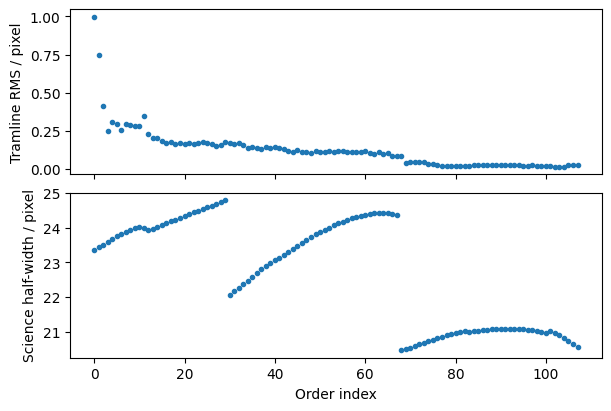

In [7]:
nightly_tramlines = tramlines.fit_nightly_tramlines(
    reduction_input,
    master_flat,
    detector_shifts,
    config,
    paths,
)

if (
    IN_NOTEBOOK
    and config.diagnostics != 'none'
):
    tramlines.show_summary(
        nightly_tramlines
    )

In [8]:
flat_products = flat.create_flat_products(
    master_flat,
    nightly_tramlines,
    config,
    paths,
)

DEBUG    ccd_1_order_167: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_166: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_165: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_164: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_163: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_162: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_161: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_160: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_159: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_158: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_157: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_156: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_155: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_154: created extr

## 6. Extract wavelength-calibration observations

**Input:** SimLC and FibTh observations  
**Output:** time-stamped extracted calibration spectra

SimLC and FibTh are both used to establish the wavelength solution.

In [9]:
calibration_spectra = tramlines.extract_calibration_spectra(
    reduction_input,
    nightly_tramlines,
    config,
    paths
)

In [10]:
for calibration_type in ['SimTh','SimLC','FibTh']:
    tramlines.save_calibration_spectra(
        calibration_spectra[calibration_type],
        paths.wavelength / f'{calibration_type.lower()}.fits',
        calibration_type=calibration_type,
        overwrite=True,
    )

In [14]:
calibration_peak_tables = calibration.measure_calibration_peaks_for_night(
    calibration_spectra,
    output_dir=paths.wavelength,
    diagnostic_dir=paths.figures / 'calibration',
    maximum_signal={
        'SimLC': None,
        'SimTh': None,
        'FibTh': None,
    },
    log_level=config.log_level,
    diagnostics=config.diagnostics,
    overwrite=config.overwrite
)

## 7. Fit the wavelength solution

**Input:** extracted SimLC + FibTh spectra and their MJD timestamps  
**Output:** wavelength calibration model for the night

In [15]:
VELOCE_CCD_ORDERS = {
    "1": np.arange(167, 138 - 1, -1),
    "2": np.arange(140, 103 - 1, -1),
    "3": np.arange(104, 65 - 1, -1),
}

initial_wavelength_solution = {}

# loop over calibration types
for calibration_type in ['SimTh','SimLC','FibTh']:
    initial_wavelength_solution[calibration_type] = {}
    # loop over ccds
    for ccd in ['1', '2', '3']:
        for order in VELOCE_CCD_ORDERS[ccd]:
            try:
                initial_wavelength_solution[calibration_type][f'ccd_{ccd}_order_{order}'] = np.loadtxt(paths.repository / f"velocereduction/wavelength_coefficients/wavelength_coefficients_ccd_{ccd}_order_{order}_lc.txt")
            except:
                initial_wavelength_solution[calibration_type][f'ccd_{ccd}_order_{order}'] = np.loadtxt(paths.repository / f"velocereduction/wavelength_coefficients/wavelength_coefficients_ccd_{ccd}_order_{order}_thxe.txt")

In [16]:
# Let's see if we can maybe first loop over all expected LC and Th peaks and identify the closest measured peaks!

calibration_type = 'SimLC'

for name in ['closest_lc_number', 'closest_lc_wavelength', 'expected_wavelength']:
    if name not in calibration_peak_tables[calibration_type].colnames:
        calibration_peak_tables[calibration_type][name] = np.zeros(len(calibration_peak_tables[calibration_type]), dtype=float)

for order in list(initial_wavelength_solution[calibration_type].keys()):
    ccd = order.split('_')[1]
    order_number = int(order.split('_')[-1])

    relevant_detector_shift_dy = detector_shifts['dy'][detector_shifts['ccd'] == int(ccd)]

    # relevant simlc peaks
    relevant_simlc_peaks = (
        (calibration_peak_tables[calibration_type]['ccd'] == int(ccd))
        & (calibration_peak_tables[calibration_type]['order'] == order_number)
    )
    len_relevant_simlc_peaks = len(np.where(relevant_simlc_peaks)[0])

    if len_relevant_simlc_peaks > 0:

        expected_wavelengths = np.polynomial.polynomial.polyval(
            calibration_peak_tables[calibration_type]['y'][relevant_simlc_peaks] - 2048 + relevant_detector_shift_dy,
            initial_wavelength_solution[calibration_type][order],
        ) * 10.

        closest_lc_number_from_expected_wavelength = np.array(np.round(utils.lasercomb_numbers_from_wavelength(expected_wavelengths)))

        if order_number == 66:
            closest_lc_number_from_expected_wavelength += 1

        closest_lc_wavelength = utils.lasercomb_wavelength_from_numbers(closest_lc_number_from_expected_wavelength)

        calibration_peak_tables[calibration_type]['expected_wavelength'][relevant_simlc_peaks] = expected_wavelengths
        calibration_peak_tables[calibration_type]['closest_lc_number'][relevant_simlc_peaks] = closest_lc_number_from_expected_wavelength
        calibration_peak_tables[calibration_type]['closest_lc_wavelength'][relevant_simlc_peaks] = closest_lc_wavelength

In [20]:
def calculate_2dimensional_wavelength_solution(
        calibration_type = 'SimLC',
        ccd = 3,
        degree_y = 7,
        degree_m = 5,
        minimum_y = 200,
        maximum_y = 3900,
        minimum_signal_to_noise = 20,
        maximum_y_uncertainty = 0.005,
        config = config,
        paths = paths
    ):

    input_peaks = (
        (calibration_peak_tables[calibration_type]['ccd'] == ccd)
        & calibration_peak_tables[calibration_type]['used_for_wavelength_fit']
        & (calibration_peak_tables[calibration_type]['y'] > minimum_y)
        & (calibration_peak_tables[calibration_type]['y'] < maximum_y)
        & (calibration_peak_tables[calibration_type]['signal_to_noise'] > minimum_signal_to_noise)
        & (calibration_peak_tables[calibration_type]['y_uncertainty'] < maximum_y_uncertainty)
        & np.isfinite(calibration_peak_tables[calibration_type]['closest_lc_wavelength'])
    )

    peak_data = calibration_peak_tables[calibration_type][input_peaks]

    m = np.asarray(peak_data['order'], dtype=float)
    y = np.asarray(peak_data['y'], dtype=float)
    y_sigma = np.asarray(peak_data['y_uncertainty'], dtype=float)

    wavelength = np.asarray(
        peak_data['closest_lc_wavelength'],
        dtype=float,
    )

    m_lambda = m * wavelength

    y_min, y_max = 0.0, 4111.0
    m_min, m_max = 65.0, 104.0

    y_mid = 0.5 * (y_min + y_max)
    y_scale = 0.5 * (y_max - y_min)

    m_mid = 0.5 * (m_min + m_max)
    m_scale = 0.5 * (m_max - m_min)

    y_norm = (y - y_mid) / y_scale
    m_norm = (m - m_mid) / m_scale

    from numpy.polynomial.legendre import (
        legvander2d,
        legval2d,
        legder,
    )

    design_matrix = legvander2d(
        y_norm,
        m_norm,
        [degree_y, degree_m],
    )

    design_matrix = design_matrix.reshape(
        len(y),
        -1,
    )

    coefficients_flat, _, _, _ = np.linalg.lstsq(
        design_matrix,
        m_lambda,
        rcond=None,
    )

    coefficients = coefficients_flat.reshape(
        degree_y + 1,
        degree_m + 1,
    )

    m_lambda_model = legval2d(
        y_norm,
        m_norm,
        coefficients,
    )

    wavelength_model = m_lambda_model / m

    wavelength_residual = (
        wavelength - wavelength_model
    )

    coefficients_dy = legder(
        coefficients,
        axis=0,
    )

    dm_lambda_dy = (
        legval2d(
            y_norm,
            m_norm,
            coefficients_dy,
        )
        / y_scale
    )

    pixel_residual = (
        m_lambda - m_lambda_model
    ) / dm_lambda_dy

    speed_of_light_mps = 299792458.0

    velocity_residual = (
        speed_of_light_mps
        * wavelength_residual
        / wavelength
    )

    if config.diagnostics != 'none':

        print(
            f'degree_y: {degree_y}'
        )
        print(
            f'degree_m: {degree_m}'
        )

        print(
            f'N lines: {len(y)}'
        )

        print(
            f'RMS pixel residual: '
            f'{np.sqrt(np.mean(pixel_residual**2)):.4f} pix'
        )

        print(
            f'Median |pixel residual|: '
            f'{np.median(np.abs(pixel_residual)):.4f} pix'
        )

        print(
            f'RMS velocity residual: '
            f'{np.sqrt(np.mean(velocity_residual**2)):.1f} m/s'
        )

    if config.diagnostics == 'full':
        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 9),
        )

        axes[0].scatter(
            y,
            pixel_residual,
            s=5,
        )

        axes[0].axhline(
            0,
            ls='--',
        )

        axes[0].set_xlabel('Dispersion pixel $y$')
        axes[0].set_ylabel('Residual [pixel]')


        axes[1].scatter(
            m,
            pixel_residual,
            s=5,
        )

        axes[1].axhline(
            0,
            ls='--',
        )

        axes[1].set_xlabel('Order $m$')
        axes[1].set_ylabel('Residual [pixel]')


        scatter = axes[2].scatter(
            y,
            m,
            c=pixel_residual,
            s=8,
        )

        axes[2].set_xlabel('Dispersion pixel $y$')
        axes[2].set_ylabel('Order $m$')

        fig.colorbar(
            scatter,
            ax=axes[2],
            label='Residual [pixel]',
        )

        plt.tight_layout()
        plt.show()
        plt.close()

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 9),
            sharex=True,
        )

        axes[0].scatter(
            y,
            pixel_residual,
            s=5,
        )
        axes[0].axhline(0, ls='--')
        axes[0].set_ylabel('Residual [pixel]')

        axes[1].scatter(
            y,
            wavelength_residual,
            s=5,
        )
        axes[1].axhline(0, ls='--')
        axes[1].set_ylabel(r'Residual [$\AA$]')

        axes[2].scatter(
            y,
            velocity_residual,
            s=5,
        )
        axes[2].axhline(0, ls='--')
        axes[2].set_ylabel(r'Residual [m s$^{-1}$]')
        axes[2].set_xlabel('Dispersion pixel $y$')

        plt.tight_layout()
        plt.show()
        plt.close()

    m_lambda_sigma = (
        np.abs(dm_lambda_dy)
        * y_sigma
    )

    weighted_design_matrix = (
        design_matrix
        / m_lambda_sigma[:, None]
    )

    weighted_m_lambda = (
        m_lambda
        / m_lambda_sigma
    )

    coefficients_flat, _, _, _ = np.linalg.lstsq(
        weighted_design_matrix,
        weighted_m_lambda,
        rcond=None,
    )

    coefficients = coefficients_flat.reshape(
        degree_y + 1,
        degree_m + 1,
    )

In [21]:
config.diagnostics = 'info'
calculate_2dimensional_wavelength_solution(ccd=2, degree_y=7, degree_m=5, minimum_y=200, maximum_y=3900, minimum_signal_to_noise=10, maximum_y_uncertainty=0.01)

degree_y: 7
degree_m: 5
N lines: 5721
RMS pixel residual: 0.0264 pix
Median |pixel residual|: 0.0177 pix
RMS velocity residual: 44.6 m/s


In [22]:
calculate_2dimensional_wavelength_solution(
    calibration_type = 'SimLC',
    ccd = 3
)

degree_y: 7
degree_m: 5
N lines: 4730
RMS pixel residual: 0.0238 pix
Median |pixel residual|: 0.0160 pix
RMS velocity residual: 38.7 m/s


In [23]:
calculate_2dimensional_wavelength_solution(ccd=3, degree_y=7, degree_m=5, minimum_y=200, maximum_y=3900, minimum_signal_to_noise=10, maximum_y_uncertainty=0.01)

degree_y: 7
degree_m: 5
N lines: 9252
RMS pixel residual: 0.0301 pix
Median |pixel residual|: 0.0208 pix
RMS velocity residual: 50.2 m/s


In [24]:
calculate_2dimensional_wavelength_solution(ccd=3)

degree_y: 7
degree_m: 5
N lines: 4730
RMS pixel residual: 0.0238 pix
Median |pixel residual|: 0.0160 pix
RMS velocity residual: 38.7 m/s


# AND NOW ON TO FibTh and SimTh!

In [ ]:
import sys
sys.exit()

SystemExit: 0

/Users/buder/opt/anaconda3/envs/py_cannon/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [26]:
import pickle

# ThAr atlas from Murphy et al. (2007)
dtype = [
    ("wavenumber", float),
    ("wave_air", float),
    ("log10_intensity", float),
    ("element", "U10"),
    ("ion", "U10"),
    ("source", "U2"),
]
thar_lines = Table(np.genfromtxt(
    paths.repository / 'velocereduction/veloce_reference_data/thar_UVES_MM090311.dat',
    dtype=dtype,
    comments="#",
    autostrip=True
))
thar_lines['wave_vac'] = utils.wavelength_air_to_vac(thar_lines['wave_air'])

delta_wavelength = 0.05
thar_lines_fine_murphy = dict()
thar_lines_fine_murphy['wave_vac'] = np.arange(thar_lines['wave_vac'][0], thar_lines['wave_vac'][-1]+delta_wavelength, delta_wavelength)
thar_lines_fine_murphy['wave_air'] = utils.wavelength_vac_to_air(thar_lines_fine_murphy['wave_vac'])
thar_lines_fine_murphy['intensity'] = np.zeros(len(thar_lines_fine_murphy['wave_vac']))
for index in range(len(thar_lines_fine_murphy['wave_vac'])):
    thar_line_in_range = np.where((thar_lines['wave_vac']-0.5*delta_wavelength < thar_lines_fine_murphy['wave_vac'][index]) & (thar_lines_fine_murphy['wave_vac'][index] < thar_lines['wave_vac']+0.5*delta_wavelength))[0]
    if len(thar_line_in_range) > 0:
        thar_lines_fine_murphy['intensity'][index] = np.mean(10**thar_lines['log10_intensity'][thar_line_in_range])

KeyboardInterrupt: 

In [ ]:
nist_th_file = paths.repository / 'velocereduction/veloce_reference_data/th_linelist_NIST.pickle'
with open(nist_th_file, 'rb') as f:
    atomic_data_dict = pickle.load(f)
th_lines = dict()
th_lines['wave_air']  = atomic_data_dict['linelist']['obs_wl_air(nm)']*10
th_lines['wave_vac']  = utils.wavelength_air_to_vac(atomic_data_dict['linelist']['obs_wl_air(nm)']*10)
th_lines['intensity'] = atomic_data_dict['linelist']['intens']

delta_wavelength = 0.05
th_lines_fine_nist = dict()
th_lines_fine_nist['wave_vac'] = np.arange(th_lines['wave_vac'][0], th_lines['wave_vac'][-1]+delta_wavelength, delta_wavelength)
th_lines_fine_nist['wave_air'] = utils.wavelength_vac_to_air(th_lines_fine_nist['wave_vac'])
th_lines_fine_nist['intensity'] = np.zeros(len(th_lines_fine_nist['wave_vac']))
for index in range(len(th_lines_fine_nist['wave_vac'])):
    th_line_in_range = np.where((th_lines['wave_vac']-0.5*delta_wavelength < th_lines_fine_nist['wave_vac'][index]) & (th_lines_fine_nist['wave_vac'][index] < th_lines['wave_vac']+0.5*delta_wavelength))[0]
    if len(th_line_in_range) > 0:
        th_lines_fine_nist['intensity'][index] = np.mean(th_lines['intensity'][th_line_in_range])

In [ ]:
def plot_th(order, ccd, y0=2048):
    # def calc_(y0):

    try:
        coefficients = np.loadtxt(paths.repository / f'velocereduction/wavelength_coefficients/wavelength_coefficients_ccd_{ccd}_order_{order}_lc.txt')
    except:
        coefficients = np.loadtxt(paths.repository / f'velocereduction/wavelength_coefficients/wavelength_coefficients_ccd_{ccd}_order_{order}_thxe.txt')
        
    simth_counts = calibration_spectra['SimTh'][str(ccd)][0]['counts'][104-order]

    y = np.arange(4112)
    # y0 = np.median(y)   # 2055.5

    detector_shift_y = detector_shifts['dy'][
        detector_shifts['ccd'] == int(ccd)
    ][0]

    y_centered = y - y0

    wavelength_reference = np.polynomial.polynomial.polyval(
        y_centered,
        coefficients,
    )*10

    wavelength_min = wavelength_reference.min()
    wavelength_max = wavelength_reference.max()

    th_lines_fine_nist_in_range = (
        (th_lines_fine_nist['wave_vac'] > wavelength_min)
        & (th_lines_fine_nist['wave_vac'] < wavelength_max)
    )

    th_lines_fine_murphy_in_range = (
        (thar_lines_fine_murphy['wave_vac'] > wavelength_min)
        & (thar_lines_fine_murphy['wave_vac'] < wavelength_max)
    )
    th_lines_fine_scidoc_in_range = (
        (th_lines_fine_scidoc['wave_vac'] > wavelength_min)
        & (th_lines_fine_scidoc['wave_vac'] < wavelength_max)
    )
    
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(15, 8),
        sharex=True,
    )

    axes[0].plot(
        wavelength_reference,
        # np.log10(simth_counts),
        simth_counts.clip(max=500),
        lw=0.8,
    )

    axes[0].plot(
        thar_lines_fine_murphy['wave_vac'][th_lines_fine_murphy_in_range],
        - 500 * thar_lines_fine_murphy['intensity'][th_lines_fine_murphy_in_range] / np.max(thar_lines_fine_murphy['intensity'][th_lines_fine_murphy_in_range]),
        color='C1',
        lw=0.5,
    )
    axes[0].plot(
        th_lines_fine_nist['wave_vac'][th_lines_fine_nist_in_range],
        - 500 * th_lines_fine_nist['intensity'][th_lines_fine_nist_in_range] / np.max(th_lines_fine_nist['intensity'][th_lines_fine_nist_in_range]),
        color='C3',
        lw=0.5,
    )
    axes[0].plot(
        th_lines_fine_scidoc['wave_vac'][th_lines_fine_scidoc_in_range],
        - 100 * th_lines_fine_scidoc['intensity'][th_lines_fine_scidoc_in_range] / np.max(th_lines_fine_scidoc['intensity'][th_lines_fine_scidoc_in_range]),
        color='C4',
        lw=0.5,
    )

    # for th_lines_fine_nist_vacuum_i, th_lines_fine_nist_air_i, th_lines_fine_nist_intensity_i in zip(
    #     th_lines_fine_nist['wave_vac'][th_lines_fine_nist_in_range],
    #     th_lines_fine_nist['wave_air'][th_lines_fine_nist_in_range],
    #     th_lines_fine_nist['intensity'][th_lines_fine_nist_in_range],
    # ):
        # axes[0].text(
        #     th_lines_fine_nist_vacuum_i,
        #     th_lines_fine_nist_intensity_i,
        #     f'{th_lines_fine_nist_air_i:.4f}',
        #     rotation=90,
        #     fontsize=6,
        #     ha='center',
        #     va='bottom',
        #     c = 'C0'
        # )
        # axes[0].scatter(
        #     th_lines_fine_nist_vacuum_i,
        #     th_lines_fine_nist_intensity_i,
        #     s=10,
        #     c='C0',
        #     alpha=0.5,
        # )
        # axes[0].axvline(
        #     th_lines_fine_nist_vacuum_i,
        #     lw=0.7,
        #     alpha=0.5,
        #     c = 'C0'
        # )

    # for murphy_wavelength_vacuum_i, murphy_wavelength_air_i, murphy_intensity_i in zip(
    #     thar_lines_fine_murphy['wave_vac'][th_lines_fine_murphy_in_range],
    #     thar_lines_fine_murphy['wave_air'][th_lines_fine_murphy_in_range],
    #     thar_lines_fine_murphy['intensity'][th_lines_fine_murphy_in_range],
    # ):
        # axes[0].text(
        #     murphy_wavelength_vacuum_i,
        #     murphy_intensity_i,
        #     f'{murphy_wavelength_air_i:.4f}',
        #     rotation=90,
        #     fontsize=6,
        #     ha='center',
        #     va='bottom',
        #     c = 'C1'
        # )
        # axes[0].scatter(
        #     murphy_wavelength_vacuum_i,
        #     murphy_intensity_i,
        #     s=10,
        #     c='C1',
        #     alpha=0.5,
        # )
        # axes[0].axvline(
        #     murphy_wavelength_vacuum_i,
        #     lw=0.7,
        #     alpha=0.5,
        #     c = 'C1'
        # )


    axes[0].set_ylabel('Wavelength')
    axes[0].set_title(
        'Murphy Th wavelengths: AIR'
    )


    axes[1].plot(
        wavelength_reference,
        np.log10(simth_counts.clip(min=1)),
        lw=0.8,
    )

    axes[1].set_ylabel('Counts')
    axes[1].set_xlabel(
        'Dispersion pixel $y$'
    )

    axes[1].set_title(
        'Murphy Th wavelengths: VACUUM'
    )

    plt.show()
    plt.close()

plot_th(order=103, ccd=3, y0=2048)

## 8. Dark Products

In [ ]:
# dark_products = utils.process_darks(
#     processed,
#     config,
#     paths
# ) 

## 9. Extract science spectra

**Input:** processed Science images + tramlines + Flat products + wavelength model  
**Output:** wavelength-calibrated Science spectra

The current default extraction is summed across the Science fibres.
A fibre-resolved extraction can use the same interface in future.

In [ ]:
# science_spectra = extraction.extract_science(
#     processed.science,
#     nightly_tramlines,
#     flat_products,
#     wavelength_solution,
#     config,
#     paths
# )

## 10. Velocities

**Input:** wavelength-calibrated Science spectra  
**Output:** barycentric corrections and first-pass radial velocities

In [ ]:
# science_spectra = velocities.add_barycentric_corrections(
#     science_spectra,
#     config,
#     paths
# )

# science_spectra = velocities.measure_initial_rvs(
#     science_spectra,
#     template='solar',
#     config=config,
#     paths=paths
# )

## 11. B-star and telluric products

**Input:** B-star observations  
**Output:** extracted B-star spectra and telluric measurements

In [ ]:
# bstar_spectra = extraction.extract_science(
#     processed.bstars,
#     nightly_tramlines,
#     flat_products,
#     wavelength_solution,
#     config,
#     paths,
#     product_type='Bstar'
# )

# telluric_products = tellurics.measure_tellurics(
#     bstar_spectra,
#     config,
#     paths
# )

## 12. Final products and reduction summary

Write the final Science FITS products, retained diagnostic figures, and
human-readable summary of the night.

In [ ]:
# utils.write_science_products(
#     science_spectra,
#     config,
#     paths
# )

# summary = utils.create_reduction_summary(
#     reduction_input=reduction_input,
#     detector_shifts=detector_shifts,
#     tramlines=nightly_tramlines,
#     wavelength_solution=wavelength_solution,
#     science_spectra=science_spectra,
#     config=config,
#     paths=paths
# )

# utils.write_reduction_summary(summary, config, paths)

In [ ]:
logger.info('Reduction completed successfully.')

print()
print('Reduction complete')
print(f'Night:    {night}')
print(f'Version:  {__version__}')
print(f'Products: {paths.root}')
print(f'Summary:  {paths.reduction_summary}')